<a href="https://colab.research.google.com/github/ArifaJannat2497/Python_Google_Colab/blob/My_coding_Colab/HR_WeedDectection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

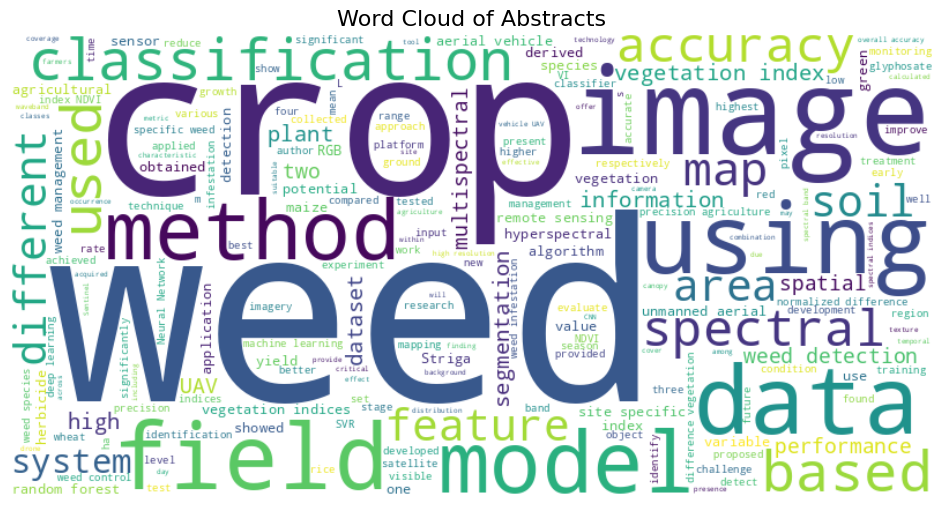

In [ ]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Step 1: Load the CSV file
# Replace with your actual filename
df = pd.read_csv("82_scopus_export_May 22-2026.csv")

# Step 2: Extract the 'Abstract' column
# Adjust column name if different
text = " ".join(str(abstract) for abstract in df['Abstract'].dropna())

# Step 3: Define stopwords (optional, to remove common words)
stopwords = set(STOPWORDS)
stopwords.update(["study", "results", "analysis"])  # add domain-specific words if needed

# Step 4: Generate the word cloud
wordcloud = WordCloud(width=800, height=400,
                      background_color="white",
                      stopwords=stopwords,
                      colormap="viridis",
                      max_words=200).generate(text)

# Step 5: Plot the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Abstracts", fontsize=16)
plt.show()


# Frequency of the words

In [ ]:
import pandas as pd
from collections import Counter
import re


# Extract abstracts
text = " ".join(str(abstract) for abstract in df['Abstract'].dropna())

# Basic preprocessing (lowercase, remove non-letters)
tokens = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())  # words with 3+ letters

# Count frequencies
word_counts = Counter(tokens)

# Show top 80 most common words
print(word_counts.most_common(80))


[('the', 1272), ('and', 854), ('weed', 310), ('for', 285), ('with', 202), ('this', 146), ('weeds', 139), ('from', 132), ('vegetation', 129), ('were', 129), ('crop', 125), ('that', 125), ('was', 119), ('data', 115), ('spectral', 114), ('using', 111), ('are', 98), ('index', 94), ('based', 92), ('images', 89), ('classification', 85), ('used', 83), ('study', 83), ('accuracy', 82), ('detection', 80), ('indices', 78), ('results', 64), ('image', 63), ('model', 62), ('field', 61), ('management', 57), ('multispectral', 56), ('high', 55), ('crops', 54), ('spatial', 54), ('uav', 53), ('specific', 51), ('methods', 50), ('fields', 49), ('analysis', 47), ('learning', 46), ('precision', 46), ('features', 46), ('different', 45), ('can', 45), ('method', 44), ('aerial', 43), ('hyperspectral', 42), ('segmentation', 42), ('ndvi', 42), ('resolution', 41), ('species', 41), ('these', 41), ('between', 41), ('information', 40), ('imagery', 40), ('which', 40), ('site', 40), ('yield', 39), ('wheat', 38), ('two',

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


            Keyword  Frequency
1              weed        310
253           weeds        139
71       vegetation        129
6              crop        125
162            data        115
272        spectral        114
180           using        111
72            index         94
291           based         92
28           images         89
26   classification         85
153           study         83
104            used         83
329        accuracy         82
16        detection         80
302         indices         78
310         results         64
49            image         63
92            model         62
60            field         61


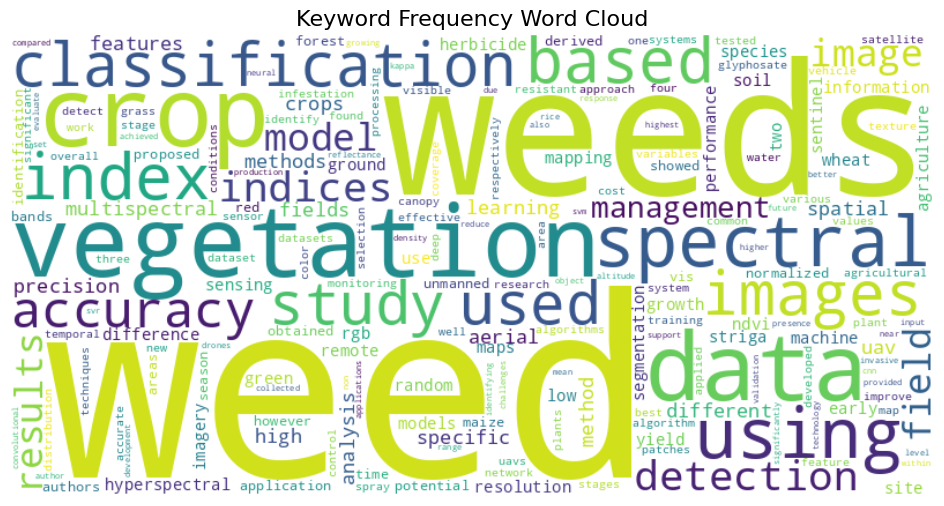

In [ ]:
import pandas as pd
from collections import Counter
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

# Download the stopwords corpus if not already downloaded
nltk.download('stopwords')


# Step 2: Extract abstracts
text = " ".join(str(abstract) for abstract in df['Abstract'].dropna())

# Step 3: Tokenize and clean text
tokens = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())  # keep words with 3+ letters

# Step 4: Remove stopwords
stop_words = set(stopwords.words('english'))
filtered_tokens = [w for w in tokens if w not in stop_words]

# Step 5: Count keyword frequencies
word_counts = Counter(filtered_tokens)

# Step 6: Convert to DataFrame for inspection
freq_df = pd.DataFrame(word_counts.items(), columns=['Keyword', 'Frequency'])
freq_df = freq_df.sort_values(by='Frequency', ascending=False)

print(freq_df.head(20))  # Top 20 keywords

# Step 7: Generate word cloud from frequencies
wc = WordCloud(width=800, height=400,
               background_color="white",
               colormap="viridis",
               max_words=200).generate_from_frequencies(word_counts)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Keyword Frequency Word Cloud", fontsize=16)
plt.show()

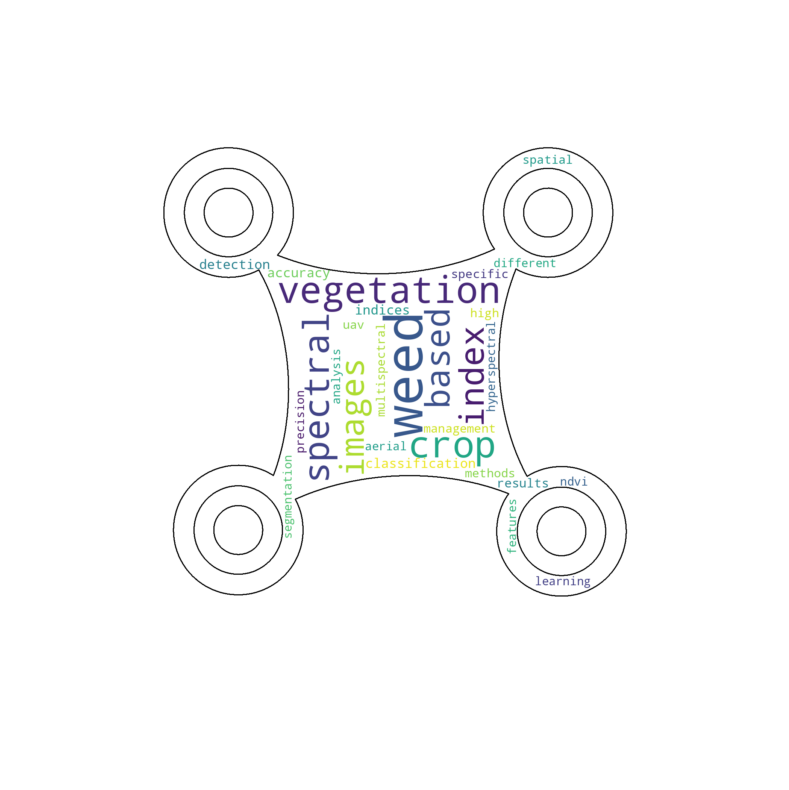

In [ ]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Keyword frequencies
keyword_freq = {
    'weed': 310, 'vegetation': 129, 'crop': 125, 'spectral': 114,
    'index': 94, 'based': 92, 'images': 89, 'classification': 85,
    'accuracy': 82, 'detection': 80, 'indices': 78, 'results': 64,
    'management': 57, 'multispectral': 56, 'high': 55, 'spatial': 54,
    'uav': 53, 'specific': 51, 'methods': 50, 'analysis': 47,
    'learning': 46, 'precision': 46, 'features': 46, 'different': 45,
    'aerial': 43, 'hyperspectral': 42, 'segmentation': 42, 'ndvi': 42
}

# Load UAV shape image
mask = np.array(Image.open("uav_shape.jpg").convert("L"))

# Invert mask if needed
mask = np.where(mask > 128, 255, 0)

# Generate word cloud
wc = WordCloud(
    background_color="white",
    mask=mask,
    contour_width=2,
    contour_color="black",
    colormap="viridis",
    max_words=200,
    prefer_horizontal=0.8,
    relative_scaling=0.3,
    min_font_size=8,
    margin=2
).generate_from_frequencies(keyword_freq)

# Plot
plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()

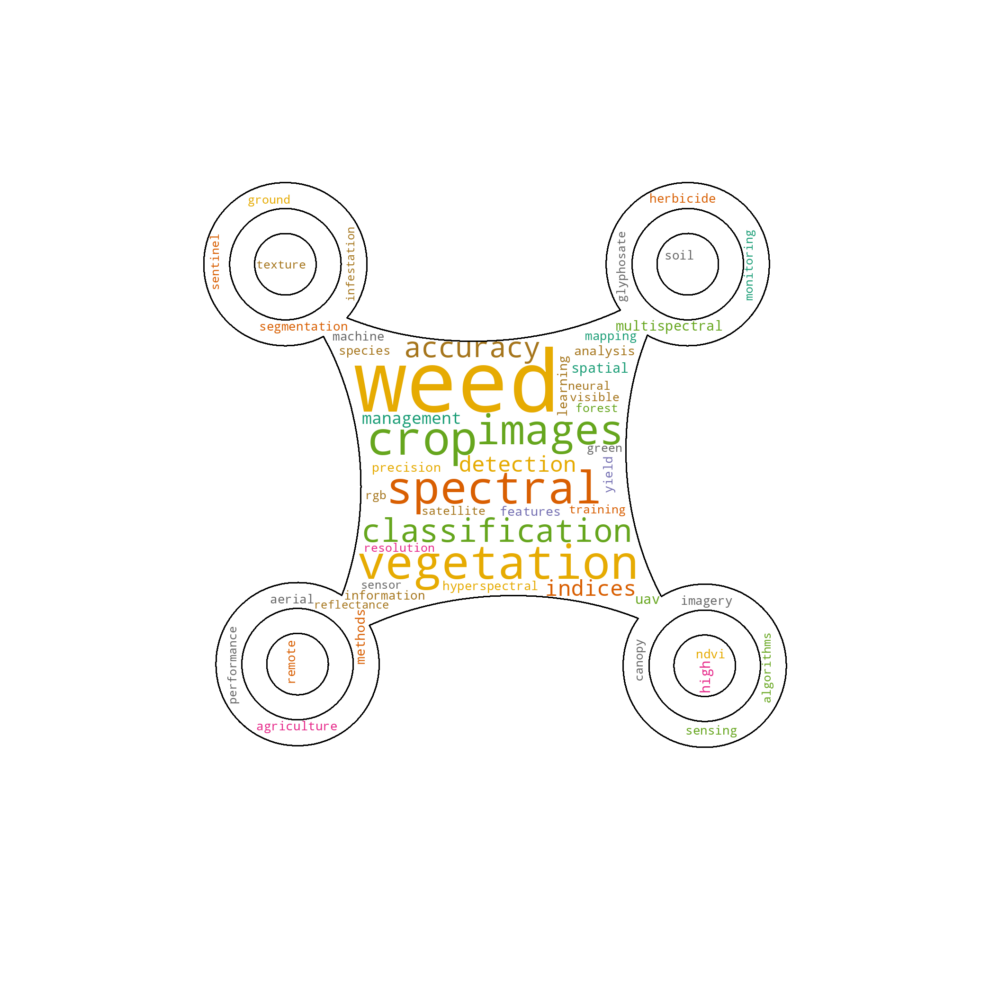

In [ ]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ==========================
# 1. Expanded keyword list
# ==========================
keyword_freq = {
    'weed': 310, 'vegetation': 129, 'crop': 125,
    'spectral': 114,
    'images': 89, 'classification': 85,
    'accuracy': 82, 'detection': 80,
    'indices': 78,
    'management': 57, 'multispectral': 56,
    'high': 55, 'spatial': 54,
    'uav': 53,
    'methods': 50, 'analysis': 47,
    'learning': 46, 'precision': 46,
    'features': 46,
    'aerial': 43, 'hyperspectral': 42,
    'segmentation': 42, 'ndvi': 42,

    # Added abstract-based terms
    'information': 40,
    'species': 40,
    'yield': 39,
    'imagery': 39,
    'agriculture': 37,
    'remote': 36,
    'sensing': 36,
    'machine': 35,
    'soil': 35,
    'mapping': 34,
    'herbicide': 34,
    'forest': 32,
    'green': 31,
    'rgb': 31,
    'ground': 30,
    'satellite': 29,
    'resolution': 29,
    'performance': 28,
    'visible': 27,
    'texture': 26,
    'algorithms': 26,
    'training': 25,
    'canopy': 25,
    'monitoring': 24,
    'sentinel': 24,
    'glyphosate': 23,
    'neural': 23,
    'infestation': 20,
    'sensor': 20,
    'reflectance': 20
}

# ==========================
# 2. Load UAV mask image
# ==========================
mask = np.array(Image.open("uav_shape.jpg").convert("L"))

# Convert to binary mask
# Black = drawable region
# White = blocked region
mask = np.where(mask < 128, 0, 255).astype(np.uint8)

# ==========================
# 3. Generate word cloud
# ==========================
wc = WordCloud(
    background_color="white",
    mask=mask,
    colormap="Dark2",

    contour_width=2,
    contour_color="black",

    max_words=300,
    prefer_horizontal=0.80,
    relative_scaling=0.35,
    min_font_size=6,
    max_font_size=180,
    margin=2,

    collocations=False,
    random_state=42
).generate_from_frequencies(keyword_freq)

# ==========================
# 4. Plot figure
# ==========================
plt.figure(figsize=(14, 10))

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")


plt.tight_layout()

plt.show()

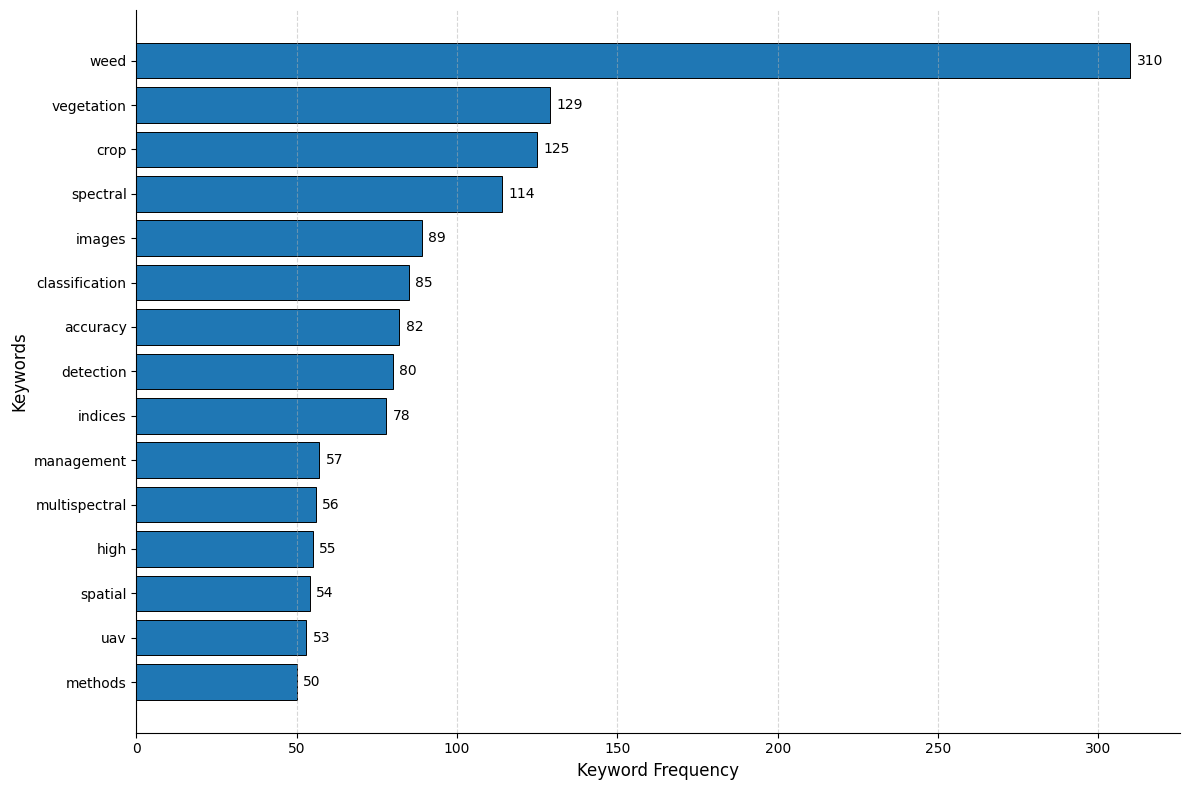

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Keyword frequencies
keyword_freq = {
    'weed': 310, 'vegetation': 129, 'crop': 125,
    'spectral': 114,
    'images': 89, 'classification': 85,
    'accuracy': 82, 'detection': 80,
    'indices': 78,
    'management': 57, 'multispectral': 56,
    'high': 55, 'spatial': 54,
    'uav': 53,
    'methods': 50, 'analysis': 47,
    'learning': 46, 'precision': 46,
    'features': 46,
    'aerial': 43, 'hyperspectral': 42,
    'segmentation': 42, 'ndvi': 42,

    'information': 40,
    'species': 40,
    'yield': 39,
    'imagery': 39,
    'agriculture': 37,
    'remote': 36,
    'sensing': 36,
    'machine': 35,
    'soil': 35,
    'mapping': 34,
    'herbicide': 34,
    'forest': 32,
    'green': 31,
    'rgb': 31,
    'ground': 30,
    'satellite': 29,
    'resolution': 29,
    'performance': 28,
    'visible': 27,
    'texture': 26,
    'algorithms': 26,
    'training': 25,
    'canopy': 25,
    'monitoring': 24,
    'sentinel': 24,
    'glyphosate': 23,
    'neural': 23,
    'infestation': 20,
    'sensor': 20,
    'reflectance': 20
}

# ==============================
# Sort data by frequency
# ==============================
sorted_items = sorted(
    keyword_freq.items(),
    key=lambda x: x[1],
    reverse=True
)

words = [x[0] for x in sorted_items][:15]  # top 20
freqs = [x[1] for x in sorted_items][:15]

# Reverse for top-to-bottom order
words = words[::-1]
freqs = freqs[::-1]

# ==============================
# Plot
# ==============================
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    words,
    freqs,
    edgecolor='black',
    linewidth=0.7
)

# Add values on bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 2,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )

# Labels
ax.set_xlabel(
    'Keyword Frequency',
    fontsize=12,
)

ax.set_ylabel(
    'Keywords',
    fontsize=12,
)

# Grid like your figure
ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

# Remove extra borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()


plt.show()